In [1]:
%matplotlib inline
%load_ext line_profiler
from itertools import combinations
import statistics

import pandas as pd
import numpy as np

import mplfinance as mpl 
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

In [2]:
from trading import create_portfolio, trade, portfolio_value
from strategies import mean_reverting_pairs
def ceil(n, d):
    return -(n // -d)

db password ········


In [3]:
from database_query import get_price_data, get_symbols_with_pd

In [4]:
def plot_heatmap(res_table, corr_df=None):
    res_table = res_table.astype('float')
    plt.figure(figsize=(1.1*len(res_table.index.values), 0.74*len(res_table.columns.values)))
    ax = sns.heatmap(res_table, annot=True, fmt=".0f", cmap='PuOr', center=1000)
    
    if corr_df is not None:
        cmap = sns.color_palette('PuOr', as_cmap=True)
        norm = mcolors.Normalize(vmin=-1, vmax=1)  # Normalize to correlation range
        
        rgb_matrix = {
            (i, j): tuple(cmap(norm(corr_df.iloc[i, j]))[:3])
            for i in range(corr_df.shape[0]) for j in range(corr_df.shape[1])
        }
    
        for i, index in enumerate(res_table.index.values):
            for j, col in enumerate(res_table.columns.values):
                if i!=j:
                    ax.add_patch(Rectangle((i,j), 1, 1, ec=rgb_matrix[i,j], fc='none', lw=2))
                
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label("Correlation")    
    
    plt.show()

In [5]:
master = get_price_data(get_symbols_with_pd(), date_range='2025-1-15::2025-1-28', default_cols=['close'])
master.close = master.close.astype('float64')
master.set_index('price_date', inplace=True)

master = master.pivot(columns=['ticker']).dropna()

tickers = ['AAPL','AMD','CSCO','GOOG','INTC','JNPR','META','MSFT','NFLX','NVDA','TSLA']

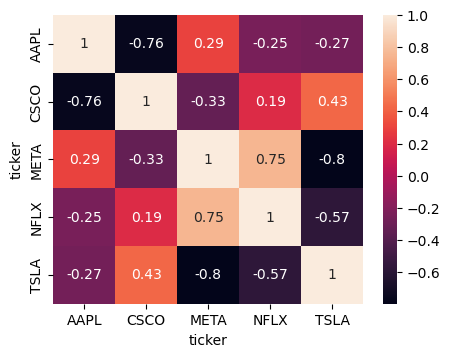

In [6]:
tickers1 = ['AAPL','CSCO','META','NFLX','TSLA']
tickers2 = ['AAPL','CSCO','META','NFLX','TSLA']

plt.figure(figsize=(len(tickers1), len(tickers1)*0.75))
corr_df = master.close.loc[:,tickers1].corr()
sns.heatmap(corr_df, annot=True)
plt.show()

In [9]:
import statsmodels.api as sm

config = {'mavg1': 5,
          'mavg2': 20,
          'm_window':8,
          'm_th': 0.1}

def mean_reverting_pairs(master,s1,s2, config=config, pair_trade=False):

    mavg1 = config['mavg1']
    mavg2= config['mavg2']
    m_window = config['m_window']
    m_th = config['m_th']
    

    
    stock_1, stock_2 = master.close[s1], master.close[s2]

    model = sm.OLS(stock_1.values, sm.add_constant(stock_2.values)).fit()
    beta = model.params[1]
    spread = stock_1 - beta * stock_2
    
    #spread = stock_1 - stock_2
    
    spread_mavg5 = spread.rolling(window=mavg1, center=False).mean()
    spread_mavg20 = spread.rolling(window=mavg2, center=False).mean()
    std_20 = spread.rolling(window=mavg2, center=False).std()
    
    zscore_20_5 = (spread_mavg5 - spread_mavg20)/std_20
    
    rolling_momentum = zscore_20_5.diff().rolling(window=m_window, center=False).mean()
    
    signals = zscore_20_5.mask((zscore_20_5<-1) & (rolling_momentum>m_th) , 'buy')
    signals = signals.mask((zscore_20_5>1) & (rolling_momentum>-m_th) , 'sell')
    signals = signals[(signals=='buy')|(signals=='sell')]

    order_book = list(zip(signals.index, list(zip([s1]*len(signals), stock_1.loc[signals.index], signals.values))))

    
    if pair_trade:
        ob_s2 = list(zip([s2]*len(signals), stock_2.loc[signals.index].values, signals.map({'buy':'sell','sell':'buy'}).values))
        order_book.extend(list(zip(signals.index, ob_s2)))    
        
    return sorted(order_book, key=lambda x: x[0])

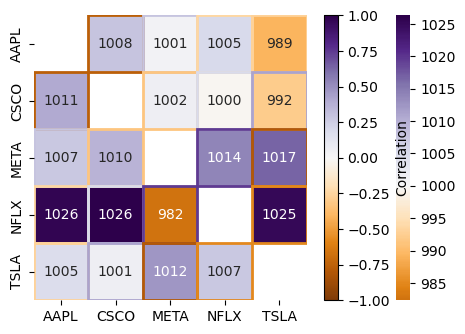

CPU times: total: 109 ms
Wall time: 403 ms


In [10]:
%%time
pairs = [(x,y) for x in tickers1 for y in tickers2 if x!=y]

config = {'mavg1': 5,
          'mavg2': 20,
          'm_window':5,
          'm_th': 0.01}

res = {}
res_table = pd.DataFrame(columns=tickers2, index=tickers1)

for s1,s2 in pairs:

    portfolio = create_portfolio(max_trade_perc=0.1)
    order_book = mean_reverting_pairs(master, s1,s2, config=config, pair_trade=False)
    
    for date, order in order_book: 
        portfolio = trade(order, portfolio)
        
    res[f'{s1},{s2}'] = (portfolio, portfolio_value(portfolio, master.loc[date].close))  
    res_table.loc[s1,s2] = res[f'{s1},{s2}'][1]['Total']


plot_heatmap(res_table, master.close.loc[:,tickers1].corr())

In [11]:
model = sm.OLS(stock_1.values, sm.add_constant(stock_2.values)).fit()
beta = model.params[1]
spread = stock_1 - beta * stock_2

NameError: name 'stock_1' is not defined

In [50]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     4785.
Date:                Fri, 28 Feb 2025   Prob (F-statistic):               0.00
Time:                        16:04:49   Log-Likelihood:                -9648.4
No. Observations:                3438   AIC:                         1.930e+04
Df Residuals:                    3436   BIC:                         1.931e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        513.1445      4.115    124.701      0.000     505.076     521.213
x1            -4.6944      0.068    -69.171      0.000      -4.827      -4.561
==============================================================================
Omnibus:                      339.918   Durbin-Watson:                   0.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              102.881
Skew:                          -0.079   Prob(JB):                     4.57e-23
Kurtosis:                       2.168   Cond. No.                     3.65e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.65e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""